# Model Analysis

Analysis of fine-tuning data and LoRA model configurations.

**Experiments:** Random, Filtered, Mixed

**Base Model:** CodeLlama-7b-Instruct-hf

In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import re
import os

sns.set_theme(style='whitegrid')

EXP_NAMES = {'experiment_1': 'Random', 'experiment_2': 'Filtered', 'experiment_3': 'Mixed'}
EXP_ORDER = ['Random', 'Filtered', 'Mixed']
COLORS = {'Random': '#3498db', 'Filtered': '#e74c3c', 'Mixed': '#2ecc71'}

base_dir = Path.cwd().parent
results_dir = base_dir / 'results'
plots_dir = Path.cwd() / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {results_dir}')
print(f'Plots dir: {plots_dir}')

Results dir: /home/sing/refactor_project/results
Plots dir: /home/sing/refactor_project/notebooks/plots


---
## 1. LoRA Model Configuration

In [28]:
lora_configs = {}
for exp_folder, exp_name in EXP_NAMES.items():
    config_file = results_dir / exp_folder / 'lora_model' / 'adapter_config.json'
    if config_file.exists():
        with open(config_file) as f:
            lora_configs[exp_name] = json.load(f)
        print(f'Loaded LoRA config for {exp_name}')

if lora_configs:
    first_config = lora_configs[list(lora_configs.keys())[0]]
    print(f'\nBase Model: {first_config.get("base_model_name_or_path", "N/A")}')
    print(f'PEFT Type: {first_config.get("peft_type", "N/A")}')
    print(f'Task Type: {first_config.get("task_type", "N/A")}')

Loaded LoRA config for Random
Loaded LoRA config for Filtered
Loaded LoRA config for Mixed

Base Model: codellama/CodeLlama-7b-Instruct-hf
PEFT Type: LORA
Task Type: CAUSAL_LM


In [29]:
if lora_configs:
    config_df = pd.DataFrame(lora_configs).T
    key_params = ['base_model_name_or_path', 'r', 'lora_alpha', 'lora_dropout', 'bias', 'task_type']
    available_params = [p for p in key_params if p in config_df.columns]
    print('LoRA Configuration Comparison:')
    display(config_df[available_params])

LoRA Configuration Comparison:


,base_model_name_or_path,r,lora_alpha,lora_dropout,bias,task_type
Random,codellama/CodeLlama-7b-Instruct-hf,16,32,0.05,none,CAUSAL_LM
Filtered,codellama/CodeLlama-7b-Instruct-hf,16,32,0.05,none,CAUSAL_LM
Mixed,codellama/CodeLlama-7b-Instruct-hf,16,32,0.05,none,CAUSAL_LM


---
## 2. Training Data Analysis

In [30]:
def parse_training_sample(text):
    """Parse [INST] instruction [/INST] response format."""
    # Extract instruction (between [INST] and [/INST])
    inst_match = re.search(r'\[INST\](.+?)\[/INST\]', text, re.DOTALL)
    instruction = inst_match.group(1).strip() if inst_match else ''
    
    # Extract response (after [/INST])
    response_match = re.search(r'\[/INST\](.+)$', text, re.DOTALL)
    response = response_match.group(1).strip() if response_match else ''
    
    # Extract refactoring type from instruction
    refactor_match = re.search(r'Apply:\s*([^.\n]+)', instruction)
    refactor_type = refactor_match.group(1).strip() if refactor_match else 'Unknown'
    
    return {
        'instruction': instruction,
        'response': response,
        'refactor_type': refactor_type,
        'instruction_len': len(instruction),
        'response_len': len(response),
        'total_len': len(text)
    }

In [31]:
training_data = {}
parsed_data = {}

for exp_folder, exp_name in EXP_NAMES.items():
    train_file = results_dir / exp_folder / 'finetune_dataset' / 'train.jsonl'
    if train_file.exists():
        samples = []
        parsed = []
        with open(train_file) as f:
            for line in f:
                sample = json.loads(line)
                samples.append(sample)
                if 'text' in sample:
                    parsed.append(parse_training_sample(sample['text']))
        training_data[exp_name] = samples
        parsed_data[exp_name] = pd.DataFrame(parsed)
        print(f'{exp_name}: {len(samples)} training samples')

if parsed_data:
    print('\nSample parsed data:')
    display(parsed_data[list(parsed_data.keys())[0]].head())

Random: 19 training samples
Filtered: 100 training samples
Mixed: 71 training samples

Sample parsed data:


,instruction,response,refactor_type,instruction_len,response_len,total_len
0,Refactor this Java code. Apply: Move Class.\nR...,```java\n/*\n * Licensed to the Apache Softwar...,Move Class,3095,3012,6122
1,Refactor this Java code. Apply: Extract Method...,```java\n/*\n * Licensed to the Apache Softwar...,Extract Method,3099,3012,6126
2,Refactor this Java code. Apply: Extract Variab...,```java\n/*\n * Licensed to the Apache Softwar...,"Extract Variable, Extract Method",3117,3012,6144
3,Refactor this Java code. Apply: Extract Variab...,```java\n/*\n * Licensed to the Apache Softwar...,Extract Variable,3101,3012,6128
4,Refactor this Java code. Apply: Extract Variab...,```java\n/*\n * Licensed to the Apache Softwar...,Extract Variable,3101,3012,6128


---
## 3. Refactoring Types in Training Data

In [32]:
if parsed_data:
    refactor_counts = {}
    for exp_name, df in parsed_data.items():
        counts = df['refactor_type'].value_counts().to_dict()
        refactor_counts[exp_name] = counts
        print(f'\n{exp_name} refactoring types:')
        for rt, count in sorted(counts.items(), key=lambda x: -x[1]):
            print(f'  {rt}: {count}')


Random refactoring types:
  Extract Variable: 7
  Extract Method: 3
  Extract Variable, Extract Method: 2
  Move Class: 1
  Extract Class, Move Attribute: 1
  Inline Variable, Move Attribute: 1
  Extract Interface: 1
  Inline Method: 1
  Push Down Method, Push Down Attribute: 1
  Pull Up Method, Extract Interface: 1

Filtered refactoring types:
  Extract Method: 20
  Extract Variable: 19
  Extract Variable, Extract Method: 14
  Inline Variable: 6
  Move Attribute: 4
  Extract And Move Method: 4
  Extract Interface: 3
  Move Method: 2
  Extract And Move Method, Extract Method: 2
  Move Attribute, Extract Class, Move Method: 2
  Inline Variable, Extract Method: 2
  Inline Method, Extract Variable, Move Class, Extract Class, Move Method, Inline Variable, Move Attribute: 1
  Extract And Move Method, Extract Variable, Extract Method: 1
  Extract And Move Method, Inline Variable, Extract Variable: 1
  Pull Up Attribute, Extract Variable, Extract Superclass, Extract Method: 1
  Move Attribut

---
## 4. Experiment Timing

In [33]:
from datetime import datetime

timing_data = {}

for exp_folder, exp_name in EXP_NAMES.items():
    config_file = results_dir / exp_folder / 'config.json'
    results_file = results_dir / exp_folder / 'results.json'

    if config_file.exists() and results_file.exists():
        with open(config_file) as f:
            config = json.load(f)

        start_str = config.get('started', '')
        start_time = datetime.strptime(start_str, '%Y-%m-%d %H:%M:%S')
        end_time = datetime.fromtimestamp(results_file.stat().st_mtime)
        duration = (end_time - start_time).total_seconds()

        hours = int(duration // 3600)
        minutes = int((duration % 3600) // 60)

        with open(results_file) as f:
            n_commits = sum(len(v) for v in json.load(f).values())

        timing_data[exp_name] = {
            'Started': start_str,
            'Duration': f'{hours}h {minutes}m',
            'Eval Commits': n_commits,
            'Time/Commit (s)': f'{duration/n_commits:.1f}' if n_commits > 0 else 'N/A'
        }

if timing_data:
    print('Experiment Timing Summary')
    print('=' * 70)
    timing_df = pd.DataFrame(timing_data).T
    display(timing_df)

Experiment Timing Summary


,Started,Duration,Eval Commits,Time/Commit (s)
Random,2026-03-30 12:12:29,2h 3m,40,185.3
Filtered,2026-03-30 06:25:57,6h 35m,200,118.7
Mixed,2026-03-30 04:02:25,1h 5m,142,27.6


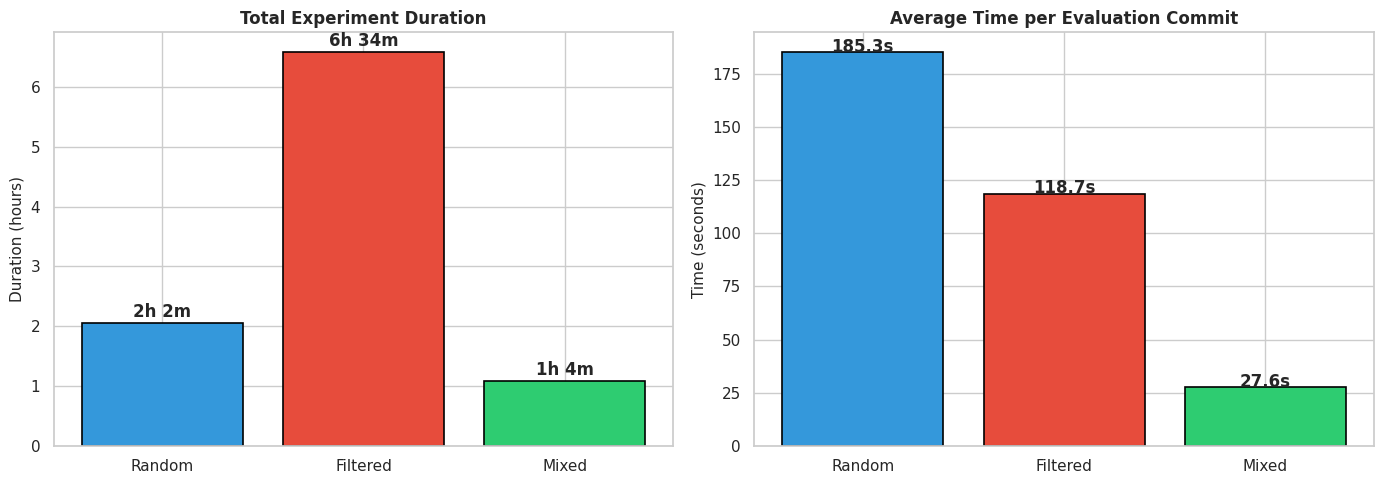

In [34]:
if timing_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Duration chart
    ax = axes[0]
    durations = []
    for exp in EXP_ORDER:
        if exp in timing_data:
            dur_str = timing_data[exp]['Duration']
            h = int(dur_str.split('h')[0])
            m = int(dur_str.split('h')[1].split('m')[0].strip())
            durations.append(h + m/60)

    bars = ax.bar(EXP_ORDER, durations, color=[COLORS[e] for e in EXP_ORDER], edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Duration (hours)', fontsize=11)
    ax.set_title('Total Experiment Duration', fontsize=12, fontweight='bold')
    for bar, dur in zip(bars, durations):
        h = int(dur)
        m = int((dur - h) * 60)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
               f'{h}h {m}m', ha='center', fontweight='bold')

    # Time per commit
    ax = axes[1]
    time_per_commit = []
    for exp in EXP_ORDER:
        if exp in timing_data:
            time_per_commit.append(float(timing_data[exp]['Time/Commit (s)']))

    bars = ax.bar(EXP_ORDER, time_per_commit, color=[COLORS[e] for e in EXP_ORDER], edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title('Average Time per Evaluation Commit', fontsize=12, fontweight='bold')
    for bar, t in zip(bars, time_per_commit):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
               f'{t:.1f}s', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(plots_dir / 'experiment_timing.png', dpi=150, bbox_inches='tight')
    plt.show()